In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

#INTEGRATOR ODE
def ode(y,model_x,model_y):
    #k1
    input_x=pd.DataFrame(data=[y],columns=['x','y'])
    input_y=pd.DataFrame(data=[y[::-1]],columns=['x','y'])
    k1 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    #k2
    input_x=pd.DataFrame(data=[y+k1/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k1/2.)[::-1]],columns=['x','y'])
    k2 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    #k3
    input_x=pd.DataFrame(data=[y+k2/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k2/2.)[::-1]],columns=['x','y'])
    k3 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    #k4
    input_x=pd.DataFrame(data=[y+k3],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k3)[::-1]],columns=['x','y'])
    k4 = np.array([h*model_x.predict({'d0':input_x})['d0'].iloc[0],h*model_y.predict({'d0':input_y})['d0'].iloc[0]])
    return [1./6.*(k1[0]+2.*k2[0]+2.*k3[0]+k4[0]),1./6.*(k1[1]+2.*k2[1]+2.*k3[1]+k4[1])]
def RK4(y0,h,t_eval,model_x,model_y):
    x=y0[0]
    y=y0[1]

    t_x=[y0[0]]
    t_y=[y0[1]]
    for i in range(len(t_eval)-1):
        diff=ode([x,y],model_x,model_y)
        x=x+diff[0]
        y=y+diff[1]
        t_x.append(x)
        t_y.append(y)
    return [t_x,t_y]

/home/oriolca/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


2026-07-10 10:55:39,956 [INFO] 
Limited Total Variation Regularization Support Detected! 
---> CVXPY is not installed. 
---> Many Total Variation Methods require CVXPY including: 
---> velocity, acceleration, jerk, jerk_sliding, smooth_acceleration
---> Please install CVXPY to use these methods.
---> Recommended to also install MOSEK and obtain a MOSEK license.
You can still use: total_variation_regularization.iterative_velocity

2026-07-10 10:55:39,957 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

2026-07-10 10:55:39,957 [INFO] 
Limited Linear Model Support Detected! 
---> CVXPY is not installed. 
---> Install CVXPY to use lineardiff derivatives 
You can still use other methods 



datasets/bact_res_SNR_20_0.csv 2026-03-23 15:24:16.396867
setting f-g links
462.693760012540
{'_a0_': 19.970033189619592, '_a1_': 0.5008688104235505}
{'_a0_': 10.027213293686197, '_a1_': 0.4967980223384632}


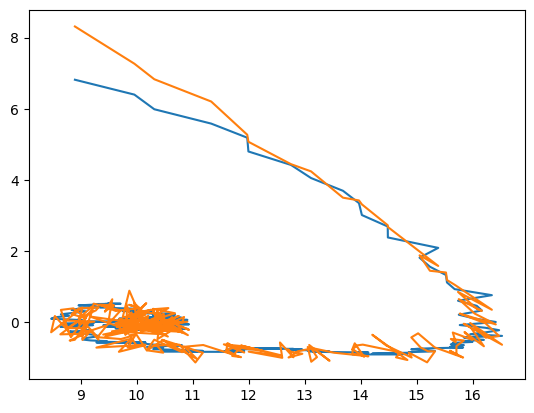

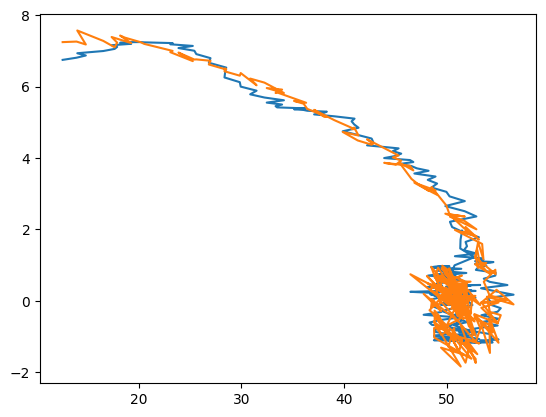

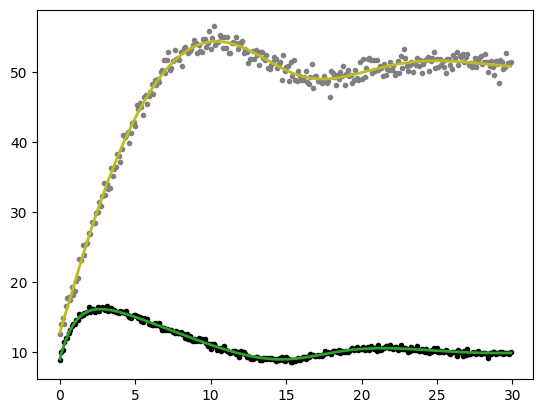

In [2]:
# Import Machine Scientist
from importlib.machinery import SourceFileLoader
import sys
from pathlib import Path
from copy import deepcopy
import pynumdiff
# Get the absolute path of the script's directory
script_dir = os.getcwd()
# Define the relative path to the module
relative_module_path = "../I-BMS-2d/mcmc_ode.py"
path = os.path.join(script_dir, relative_module_path)
mcmc_ode = SourceFileLoader("mcmc_ode", path).load_module()

#Import prior
path = os.path.join(script_dir, "../I-BMS-2d/Prior/")
sys.path.append(path)
from fit_prior import read_prior_par
prior = read_prior_par('../I-BMS-2d/Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat')

files = [str(f) for f in Path("datasets").glob("bact_res_SNR_20_0.csv")]
for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_IBMS.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    
    dx['d0'] = [ pd.DataFrame(data={'x':x_hat,'y':y_hat}),
                pd.DataFrame(data={'x':dxdt_hat,'y':dydt_hat})]
    
    dy['d0'] = [ pd.DataFrame(data={'x':y_hat,'y':x_hat}),
                pd.DataFrame(data={'x':dydt_hat,'y':dxdt_hat})]
    pms_x = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=x,
        dx=dx,
        prior_par=prior,
        from_string = '(_a0_ + ((-1 * x) + (((-1 * x) * y) / (1 + (_a1_ * pow2(x))))))'
    )
    pms_y = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=y,
        dx=dy,
        prior_par=prior,
        from_string ='(_a0_ + (((-1 * y) * x) / (1 + (_a1_ * pow2(y)))))'
    )
    print("setting f-g links")
    pms_x.fy = pms_y
    pms_y.fy = pms_x
    # print('refit')
    pms_x.get_bic(reset=True, fit=True)
    pms_x.get_energy(bic=True, reset=True)
    print(pms_x.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])
    
    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)
    
    plt.plot(pms_x.x['d0']['x'],pms_x.dx['d0'][1]['x'])
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    
    plt.plot(pms_x.x['d0']['y'],pms_x.dx['d0'][1]['y'])
    plt.plot(pms_x.x['d0']['y'],pred_y['d0'])

    data = pms_x.x['d0']
    plt.show()

    
    h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
    sol=RK4([pms_x.x0[str(pms_x)][str(pms_y)]['d0'],
          pms_y.x0[str(pms_y)][str(pms_x)]['d0']], h ,data.t.to_numpy(),pms_x,pms_y)
    
    plt.scatter(data.t,data.x, marker='.',c='k', label = 'data x(t)')
    plt.scatter(data.t,data.y, marker='.',c='grey', label = 'data y(t)')
    plt.plot(data.t,sol[0],c='tab:green', lw=2, label = 'model x(t)')
    plt.plot(data.t,sol[1],c='tab:olive', lw=2, label = 'model y(t)')
    plt.show()

datasets/bar_mag_SNR_20_0.csv 2026-03-23 15:24:17.139867
setting f-g links
-509.580825301091
{'_a0_': 0.5039310689340866}
{'_a0_': 0.49710215833135724}


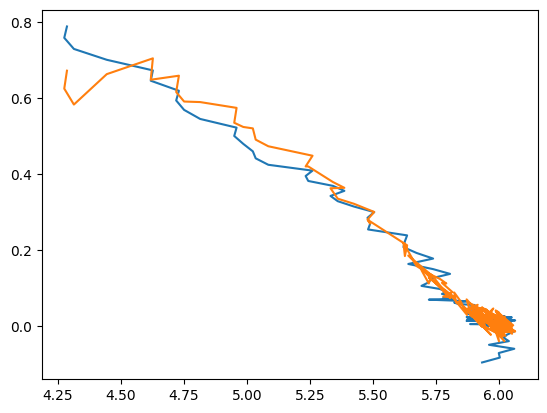

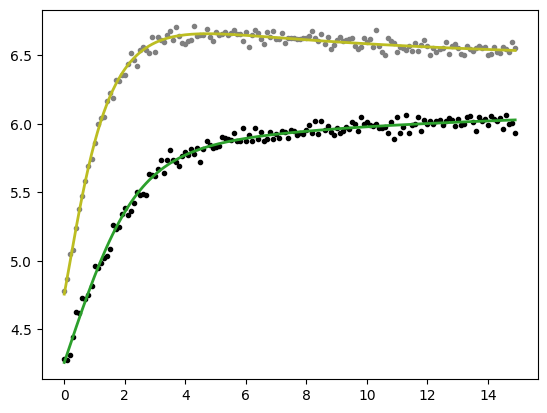

In [3]:
files = [str(f) for f in Path("datasets").glob("bar_mag_SNR_20_0.csv")]

for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_IBMS.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    
    dx['d0'] = [ pd.DataFrame(data={'x':x_hat,'y':y_hat}),
                pd.DataFrame(data={'x':dxdt_hat,'y':dydt_hat})]
    
    dy['d0'] = [ pd.DataFrame(data={'x':y_hat,'y':x_hat}),
                pd.DataFrame(data={'x':dydt_hat,'y':dxdt_hat})]
    pms_x = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=x,
        dx=dx,
        prior_par=prior,
        from_string = '((_a0_ * sin((x - y))) - sin(x))'
    )
    pms_y = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=y,
        dx=dy,
        prior_par=prior,
        from_string ='((_a0_ * sin((x - y))) - sin(x))'
    )
    print("setting f-g links")
    pms_x.fy = pms_y
    pms_y.fy = pms_x
    # print('refit')
    pms_x.get_bic(reset=True, fit=True)
    pms_x.get_energy(bic=True, reset=True)
    print(pms_x.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])

    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)

    plt.plot(pms_x.x['d0']['x'],pms_x.dx['d0'][1]['x'])
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()

    h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
    sol=RK4([pms_x.x0[str(pms_x)][str(pms_y)]['d0'],
          pms_y.x0[str(pms_y)][str(pms_x)]['d0']], h ,data.t.to_numpy(),pms_x,pms_y)
    
    plt.scatter(data.t,data.x, marker='.',c='k', label = 'data x(t)')
    plt.scatter(data.t,data.y, marker='.',c='grey', label = 'data y(t)')
    plt.plot(data.t,sol[0],c='tab:green', lw=2, label = 'model x(t)')
    plt.plot(data.t,sol[1],c='tab:olive', lw=2, label = 'model y(t)')
    plt.show()

datasets/glider_SNR_20_0.csv 2026-03-23 15:24:17.926867
###############################################
datasets/glider_SNR_20_0.csv
{'x': ((_a6_ + x) * _a1_), 'y': (cos((y ** -(x))) * (_a5_ ** y))}
457.998952702008
setting f-g links


<lambdifygenerated-3763>:2: RuntimeWarning: overflow encountered in scalar power
  return _a0_*x**2 - sin(y)
<lambdifygenerated-3763>:2: RuntimeWarning: invalid value encountered in sin
  return _a0_*x**2 - sin(y)
<lambdifygenerated-3764>:2: RuntimeWarning: invalid value encountered in cos
  return y - cos(x)/y


216.209754790465
{'_a0_': -0.05226447551885992}
{}


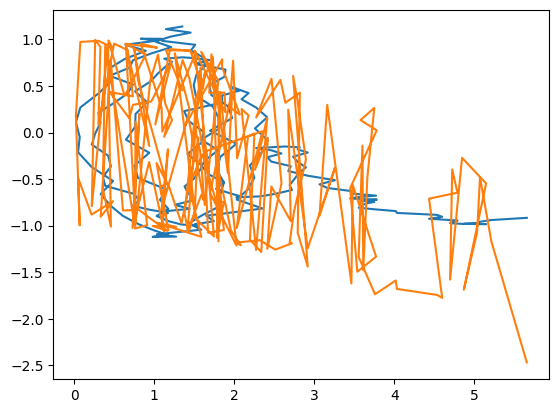

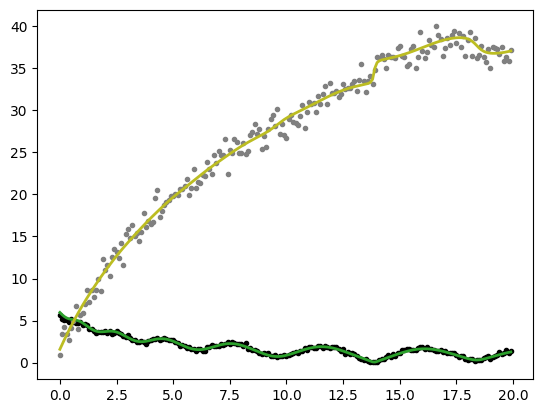

In [4]:
files = [str(f) for f in Path("datasets").glob("glider_SNR_20_0.csv")]

for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_IBMS.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    
    dx['d0'] = [ pd.DataFrame(data={'x':x_hat,'y':y_hat}),
                pd.DataFrame(data={'x':dxdt_hat,'y':dydt_hat})]
    
    dy['d0'] = [ pd.DataFrame(data={'x':y_hat,'y':x_hat}),
                pd.DataFrame(data={'x':dydt_hat,'y':dxdt_hat})]
    pms_x = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=x,
        dx=dx,
        prior_par=prior,
        from_string = '((_a0_ * pow2(x)) - sin(y))'
    )
    pms_y = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=y,
        dx=dy,
        prior_par=prior,
        from_string ='(y - (cos(x) / y))'
    )
    print("setting f-g links")
    pms_x.fy = pms_y
    pms_y.fy = pms_x
    # print('refit')
    pms_x.get_bic(reset=True, fit=True)
    pms_x.get_energy(bic=True, reset=True)
    print(pms_x.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])

    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)

    plt.plot(pms_x.x['d0']['x'],pms_x.dx['d0'][1]['x'])
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
    sol=RK4([pms_x.x0[str(pms_x)][str(pms_y)]['d0'],
          pms_y.x0[str(pms_y)][str(pms_x)]['d0']], h ,data.t.to_numpy(),pms_x,pms_y)
    
    plt.scatter(data.t,data.x, marker='.',c='k', label = 'data x(t)')
    plt.scatter(data.t,data.y, marker='.',c='grey', label = 'data y(t)')
    plt.plot(data.t,sol[0],c='tab:green', lw=2, label = 'model x(t)')
    plt.plot(data.t,sol[1],c='tab:olive', lw=2, label = 'model y(t)')
    plt.show()

datasets/lotka_volterra_SNR_20_0.csv 2026-03-23 15:24:18.615867
setting f-g links


<lambdifygenerated-14211>:2: RuntimeWarning: overflow encountered in scalar multiply
  return _a0_*x + _a1_*x*y + _a2_*x**2
<lambdifygenerated-14211>:2: RuntimeWarning: overflow encountered in scalar power
  return _a0_*x + _a1_*x*y + _a2_*x**2
<lambdifygenerated-14211>:2: RuntimeWarning: invalid value encountered in scalar add
  return _a0_*x + _a1_*x*y + _a2_*x**2
<lambdifygenerated-14212>:2: RuntimeWarning: overflow encountered in scalar power
  return _a0_*x + _a1_*x*y + _a2_*x**2
<lambdifygenerated-14212>:2: RuntimeWarning: invalid value encountered in scalar add
  return _a0_*x + _a1_*x*y + _a2_*x**2
<lambdifygenerated-14212>:2: RuntimeWarning: overflow encountered in scalar multiply
  return _a0_*x + _a1_*x*y + _a2_*x**2


-467.251521425687
{'_a0_': 3.0920683223063063, '_a1_': -2.06759369000044, '_a2_': -0.9364768409616027}
{'_a0_': 1.9732194053630705, '_a1_': -1.01719667855891, '_a2_': -0.9856045998816874}


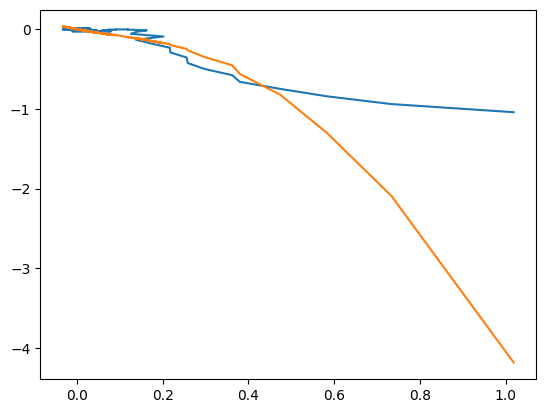

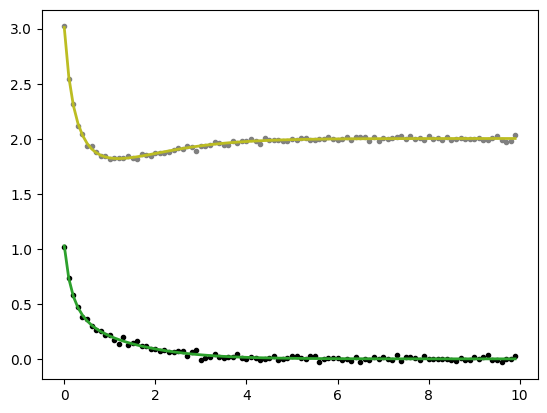

In [12]:
files = [str(f) for f in Path("datasets").glob("lotka_volterra_SNR_20_0.csv")]

for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_IBMS.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    
    dx['d0'] = [ pd.DataFrame(data={'x':x_hat,'y':y_hat}),
                pd.DataFrame(data={'x':dxdt_hat,'y':dydt_hat})]
    
    dy['d0'] = [ pd.DataFrame(data={'x':y_hat,'y':x_hat}),
                pd.DataFrame(data={'x':dydt_hat,'y':dxdt_hat})]
    pms_x = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=x,
        dx=dx,
        prior_par=prior,
        from_string = '((_a0_ * x) + ((_a1_ * (x * y)) + (_a2_ * pow2(x))))'
    )
    pms_y = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=y,
        dx=dy,
        prior_par=prior,
        from_string ='((_a0_ * x) + ((_a1_ * (x * y)) + (_a2_ * pow2(x))))'
    )
    print("setting f-g links")
    pms_x.fy = pms_y
    pms_y.fy = pms_x
    # print('refit')
    pms_x.get_bic(reset=True, fit=True)
    pms_x.get_energy(bic=True, reset=True)
    print(pms_x.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])

    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)

    plt.plot(pms_x.x['d0']['x'],pms_x.dx['d0'][1]['x'])
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
    sol=RK4([pms_x.x0[str(pms_x)][str(pms_y)]['d0'],
          pms_y.x0[str(pms_y)][str(pms_x)]['d0']], h ,data.t.to_numpy(),pms_x,pms_y)
    
    plt.scatter(data.t,data.x, marker='.',c='k', label = 'data x(t)')
    plt.scatter(data.t,data.y, marker='.',c='grey', label = 'data y(t)')
    plt.plot(data.t,sol[0],c='tab:green', lw=2, label = 'model x(t)')
    plt.plot(data.t,sol[1],c='tab:olive', lw=2, label = 'model y(t)')
    plt.show()

datasets/pred_prey_SNR_20_0.csv 2026-03-23 15:24:19.293867
setting f-g links


<lambdifygenerated-12941>:2: RuntimeWarning: overflow encountered in scalar multiply
  return x*(_a0_ - x - y/(_a1_ + x))
<lambdifygenerated-12942>:2: RuntimeWarning: overflow encountered in scalar multiply
  return x*(-_a0_*x + y/(_a1_ + y))
<lambdifygenerated-12941>:2: RuntimeWarning: invalid value encountered in scalar divide
  return x*(_a0_ - x - y/(_a1_ + x))
<lambdifygenerated-12942>:2: RuntimeWarning: invalid value encountered in scalar divide
  return x*(-_a0_*x + y/(_a1_ + y))
/home/oriolca/.local/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2502: RuntimeWarning: invalid value encountered in scalar multiply
  tmp2 = (x - v) * (fx - fw)


-79.0741598667511
(x * (_a0_ - (x + (y / (_a1_ + x)))))
{'_a0_': 4.028133542993461, '_a1_': 0.9850957054998571}
(x * ((y / (_a1_ + y)) - (_a0_ * x)))
{'_a1_': 0.9741547904623767, '_a0_': 0.07609331968640852}


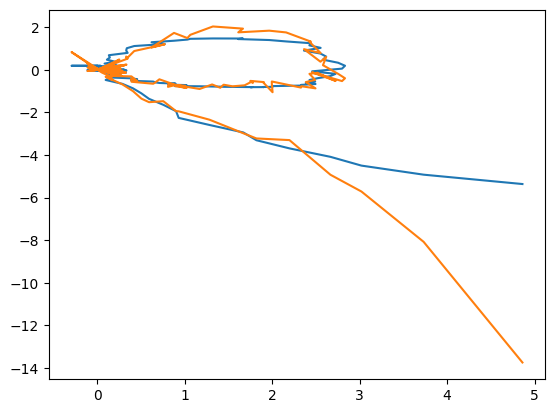

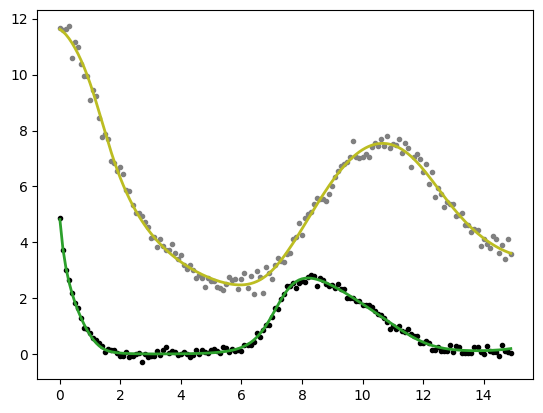

In [11]:
files = [str(f) for f in Path("datasets").glob("pred_prey_SNR_20_0.csv")]

for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_IBMS.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    
    dx['d0'] = [ pd.DataFrame(data={'x':x_hat,'y':y_hat}),
                pd.DataFrame(data={'x':dxdt_hat,'y':dydt_hat})]
    
    dy['d0'] = [ pd.DataFrame(data={'x':y_hat,'y':x_hat}),
                pd.DataFrame(data={'x':dydt_hat,'y':dxdt_hat})]
    pms_x = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=x,
        dx=dx,
        prior_par=prior,
        from_string = '(x * (_a0_ - (x + (y / (_a1_ + x)))))'
    )
    pms_y = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=y,
        dx=dy,
        prior_par=prior,
        from_string ='(x * ((y / (_a1_ + y)) - (_a0_ * x)))'
    )
    print("setting f-g links")
    pms_x.fy = pms_y
    pms_y.fy = pms_x
    # print('refit')
    pms_x.get_bic(reset=True, fit=True)
    pms_x.get_energy(bic=True, reset=True)
    print(pms_x.E)
    print(pms_x)
    print(pms_x.par_values['d0'])
    print(pms_y)
    print(pms_y.par_values['d0'])

    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)

    plt.plot(pms_x.x['d0']['x'],pms_x.dx['d0'][1]['x'])
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
    sol=RK4([pms_x.x0[str(pms_x)][str(pms_y)]['d0'],
          pms_y.x0[str(pms_y)][str(pms_x)]['d0']], h ,data.t.to_numpy(),pms_x,pms_y)
    
    plt.scatter(data.t,data.x, marker='.',c='k', label = 'data x(t)')
    plt.scatter(data.t,data.y, marker='.',c='grey', label = 'data y(t)')
    plt.plot(data.t,sol[0],c='tab:green', lw=2, label = 'model x(t)')
    plt.plot(data.t,sol[1],c='tab:olive', lw=2, label = 'model y(t)')
    plt.show()

datasets/sh_flow_SNR_20_0.csv 2026-03-23 15:24:20.024867
setting f-g links
-368.386426405113
{}
{'_a0_': 0.09767700120715321}


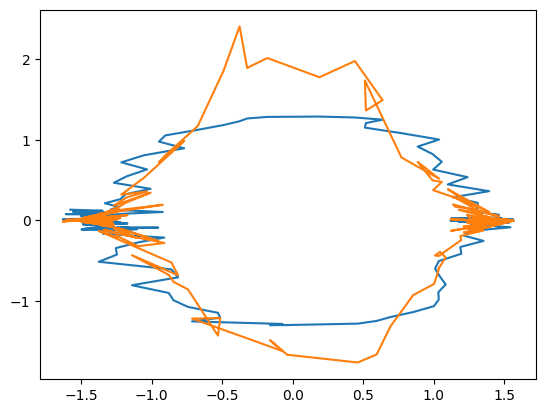

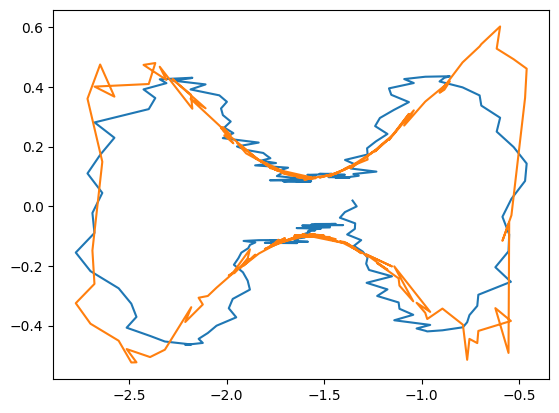

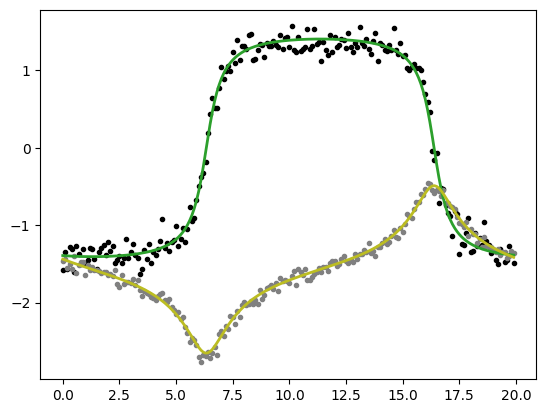

In [7]:
files = [str(f) for f in Path("datasets").glob("sh_flow_SNR_20_0.csv")]

for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_IBMS.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    
    dx['d0'] = [ pd.DataFrame(data={'x':x_hat,'y':y_hat}),
                pd.DataFrame(data={'x':dxdt_hat,'y':dydt_hat})]
    
    dy['d0'] = [ pd.DataFrame(data={'x':y_hat,'y':x_hat}),
                pd.DataFrame(data={'x':dydt_hat,'y':dxdt_hat})]
    pms_x = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=x,
        dx=dx,
        prior_par=prior,
        from_string = '(cos(x) / tan(y))'
    )
    pms_y = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=y,
        dx=dy,
        prior_par=prior,
        from_string ='(sin(y) * (pow2(cos(x)) + (_a0_ * pow2(sin(x)))))'
    )
    print("setting f-g links")
    pms_x.fy = pms_y
    pms_y.fy = pms_x
    # print('refit')
    pms_x.get_bic(reset=True, fit=True)
    pms_x.get_energy(bic=True, reset=True)
    print(pms_x.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])

    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)

    plt.plot(pms_x.x['d0']['x'],pms_x.dx['d0'][1]['x'])
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    
    plt.plot(pms_x.x['d0']['y'],pms_x.dx['d0'][1]['y'])
    plt.plot(pms_x.x['d0']['y'],pred_y['d0'])
    plt.show()
    h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
    sol=RK4([pms_x.x0[str(pms_x)][str(pms_y)]['d0'],
          pms_y.x0[str(pms_y)][str(pms_x)]['d0']], h ,data.t.to_numpy(),pms_x,pms_y)
    
    plt.scatter(data.t,data.x, marker='.',c='k', label = 'data x(t)')
    plt.scatter(data.t,data.y, marker='.',c='grey', label = 'data y(t)')
    plt.plot(data.t,sol[0],c='tab:green', lw=2, label = 'model x(t)')
    plt.plot(data.t,sol[1],c='tab:olive', lw=2, label = 'model y(t)')
    plt.show()

datasets/vd_pol_SNR_20_0.csv 2026-03-23 15:24:20.710867
setting f-g links


<lambdifygenerated-9167>:2: RuntimeWarning: overflow encountered in scalar power
  return _a0_*(_a1_*(-x**3 + x) + y)
<lambdifygenerated-9167>:2: RuntimeWarning: invalid value encountered in scalar add
  return _a0_*(_a1_*(-x**3 + x) + y)
/home/oriolca/.local/lib/python3.10/site-packages/scipy/optimize/_optimize.py:2502: RuntimeWarning: invalid value encountered in scalar multiply
  tmp2 = (x - v) * (fx - fw)


-554.224829635031
{'_a0_': 9.296667738901402, '_a1_': 0.31675612438586453}
{'_a0_': -0.09942297451933844}


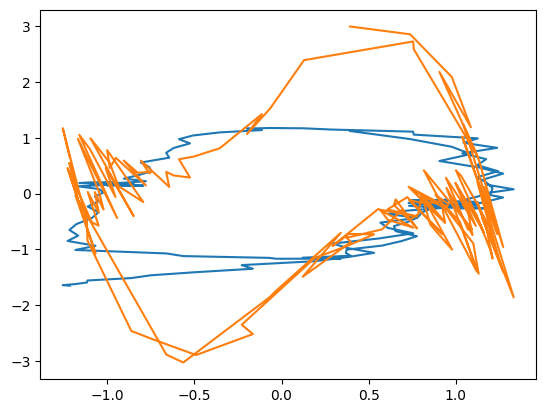

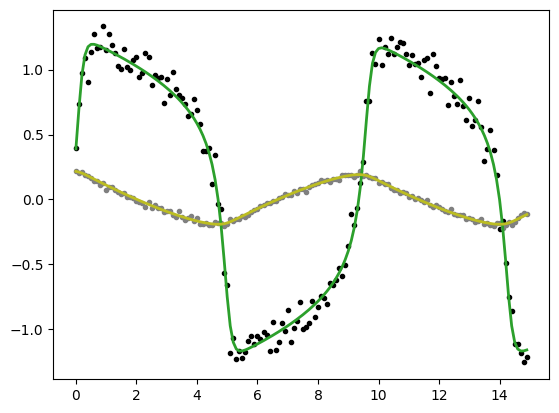

In [8]:
files = [str(f) for f in Path("datasets").glob("vd_pol_SNR_20_0.csv")]

for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_IBMS.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    
    dx['d0'] = [ pd.DataFrame(data={'x':x_hat,'y':y_hat}),
                pd.DataFrame(data={'x':dxdt_hat,'y':dydt_hat})]
    
    dy['d0'] = [ pd.DataFrame(data={'x':y_hat,'y':x_hat}),
                pd.DataFrame(data={'x':dydt_hat,'y':dxdt_hat})]
    pms_x = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=x,
        dx=dx,
        prior_par=prior,
        from_string = '(_a0_ * (y + (_a1_ * (x - pow3(x)))))'#'(pow3(y) * _a5_)'
    )
    pms_y = mcmc_ode.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=y,
        dx=dy,
        prior_par=prior,
        from_string ='(y * _a0_)'#'(_a3_ * cos((_a7_ + y)))'
    )
    print("setting f-g links")
    pms_x.fy = pms_y
    pms_y.fy = pms_x
    # print('refit')
    pms_x.get_bic(reset=True, fit=True)
    pms_x.get_energy(bic=True, reset=True)
    print(pms_x.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])

    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)

    plt.plot(pms_x.x['d0']['x'],pms_x.dx['d0'][1]['x'])
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
    sol=RK4([pms_x.x0[str(pms_x)][str(pms_y)]['d0'],
          pms_y.x0[str(pms_y)][str(pms_x)]['d0']], h ,data.t.to_numpy(),pms_x,pms_y)
    
    plt.scatter(data.t,data.x, marker='.',c='k', label = 'data x(t)')
    plt.scatter(data.t,data.y, marker='.',c='grey', label = 'data y(t)')
    plt.plot(data.t,sol[0],c='tab:green', lw=2, label = 'model x(t)')
    plt.plot(data.t,sol[1],c='tab:olive', lw=2, label = 'model y(t)')
    plt.show()